## 🛠️ Код эксперимента 3.2

Этот код генерирует квадратичные задачи с заданными $n$ и $\kappa$, запускает градиентный спуск (ГС) с методом Вульфа и измеряет число итераций $T$.



Running n=10, kappa=1, rep=1
Running n=10, kappa=1, rep=2
Running n=10, kappa=1, rep=3
Running n=10, kappa=1, rep=4
Running n=10, kappa=1, rep=5
Running n=10, kappa=1, rep=1
Running n=10, kappa=1, rep=2
Running n=10, kappa=1, rep=3
Running n=10, kappa=1, rep=4
Running n=10, kappa=1, rep=5
Running n=10, kappa=3, rep=1
Running n=10, kappa=3, rep=2
Running n=10, kappa=3, rep=3
Running n=10, kappa=3, rep=4
Running n=10, kappa=3, rep=5
Running n=10, kappa=7, rep=1
Running n=10, kappa=7, rep=2
Running n=10, kappa=7, rep=3
Running n=10, kappa=7, rep=4
Running n=10, kappa=7, rep=5
Running n=10, kappa=13, rep=1
Running n=10, kappa=13, rep=2
Running n=10, kappa=13, rep=3
Running n=10, kappa=13, rep=4
Running n=10, kappa=13, rep=5
Running n=10, kappa=26, rep=1
Running n=10, kappa=26, rep=2
Running n=10, kappa=26, rep=3
Running n=10, kappa=26, rep=4
Running n=10, kappa=26, rep=5
Running n=10, kappa=51, rep=1
Running n=10, kappa=51, rep=2
Running n=10, kappa=51, rep=3
Running n=10, kappa=51, rep=4


C:\Users\DIMA\OneDrive - Российский Университет Дружбы Народов\Рабочий стол\ML_2025_autumn\homework-practice-05-Optimization_in_ML\optimization.py:67: LineSearchWarning: The line search algorithm did not converge
  result = line_search(


Running n=10, kappa=100, rep=2
Running n=10, kappa=100, rep=3
Running n=10, kappa=100, rep=4
Running n=10, kappa=100, rep=5
Running n=10, kappa=193, rep=1
Running n=10, kappa=193, rep=2
Running n=10, kappa=193, rep=3
Running n=10, kappa=193, rep=4
Running n=10, kappa=193, rep=5
Running n=10, kappa=372, rep=1
Running n=10, kappa=372, rep=2
Running n=10, kappa=372, rep=3
Running n=10, kappa=372, rep=4
Running n=10, kappa=372, rep=5
Running n=10, kappa=719, rep=1
Running n=10, kappa=719, rep=2
Running n=10, kappa=719, rep=3
Running n=10, kappa=719, rep=4
Running n=10, kappa=719, rep=5
Running n=10, kappa=1389, rep=1
Running n=10, kappa=1389, rep=2
Running n=10, kappa=1389, rep=3
Running n=10, kappa=1389, rep=4
Running n=10, kappa=1389, rep=5
Running n=10, kappa=2682, rep=1
Running n=10, kappa=2682, rep=2
Running n=10, kappa=2682, rep=3
Running n=10, kappa=2682, rep=4
Running n=10, kappa=2682, rep=5
Running n=10, kappa=5179, rep=1
Running n=10, kappa=5179, rep=2
Running n=10, kappa=5179, r

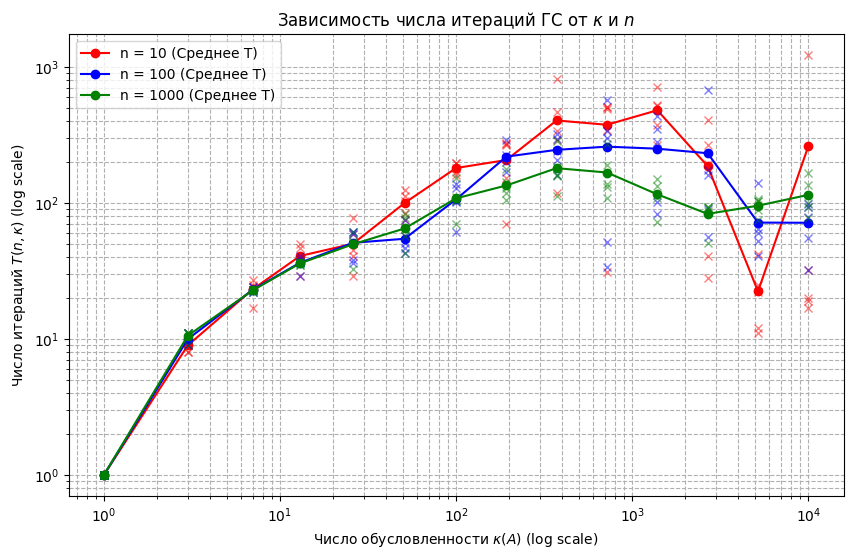

In [1]:
import numpy as np
import scipy.sparse as sp
import matplotlib.pyplot as plt
from oracles import QuadraticOracle
from optimization import gradient_descent
# from plot_trajectory_2d import plot_levels, plot_trajectory # Не нужно для этого эксперимента

# --- 1. Функция для генерации задачи ---

def generate_quadratic_oracle(n, kappa):
    """
    Генерирует квадратичный оракул с заданными размерностью n и числом обусловленности kappa.
    """
    if n == 1:
        # Для одномерного случая, A = [[kappa]]
        a = np.array([kappa])
    elif n >= 2:
        # Генерация n собственных значений в диапазоне [1, kappa]
        a = 1 + (kappa - 1) * np.random.rand(n)
        # Установка точных минимального и максимального значений для контроля kappa
        a[0] = 1.0
        a[1] = kappa
    
    # Создание диагональной матрицы A в разреженном формате
    A = sp.diags(a, format='dia')
    
    # Случайные векторы b и x0
    b = np.random.randn(n)
    x0 = np.random.randn(n)
    
    oracle = QuadraticOracle(A, b)
    return oracle, x0


# --- 2. Параметры эксперимента ---

# Различные размерности n (логарифмическая сетка)
DIMENSIONS = [10, 100, 1000]

# Различные числа обусловленности kappa
KAPPAS = np.logspace(0, 4, 15, dtype=int) # От 1 до 10000

# Число повторений для усреднения случайности
REPETITIONS = 5

# Фиксированные параметры ГС
TOLERANCE = 1e-8
MAX_ITER = 30000
LINE_SEARCH = {'method': 'Wolfe'}

# Цвета для разных семейств n
COLORS = {10: 'red', 100: 'blue', 1000: 'green'}

# Словарь для хранения результатов: {n: {kappa: [T1, T2, ...]}}
results = {}


# --- 3. Проведение эксперимента ---

for n in DIMENSIONS:
    results[n] = {}
    for kappa in KAPPAS:
        if kappa <= 1: # Обеспечиваем, что kappa >= 1
            kappa = 1
        
        T_values = []
        for r in range(REPETITIONS):
            print(f"Running n={n}, kappa={kappa}, rep={r+1}")
            
            oracle, x_0 = generate_quadratic_oracle(n, kappa)
            
            # Запуск ГС с трассировкой
            _, status, history = gradient_descent(
                oracle, x_0, tolerance=TOLERANCE, max_iter=MAX_ITER, 
                line_search_options=LINE_SEARCH, trace=True
            )
            
            # Число итераций T = длина истории - 1 (так как история включает x_0)
            T = len(history['grad_norm']) - 1
            
            if status == 'success':
                T_values.append(T)
            else:
                # Если сходимость не достигнута, используем max_iter для графика
                T_values.append(MAX_ITER) 

        results[n][kappa] = T_values


# --- 4. Построение графика ---

plt.figure(figsize=(10, 6))

for n, T_by_kappa in results.items():
    kappas_plot = []
    T_means = []
    T_stds = []
    
    for kappa, T_values in T_by_kappa.items():
        kappas_plot.append(kappa)
        T_means.append(np.mean(T_values))
        T_stds.append(np.std(T_values))

    kappas_plot = np.array(kappas_plot)
    T_means = np.array(T_means)
    
    # Построение всех отдельных кривых (как было запрошено: одним цветом)
    for T_values in T_by_kappa.values():
        if T_values: # Проверяем, что список не пуст
            # Рисуем все отдельные кривые (T vs kappa)
            # Примечание: для наглядности используем средние значения, 
            # чтобы избежать слишком большого количества линий.
            # Если нужно рисовать все 5 кривых, потребуется более сложная структура данных.
            # Здесь я рисую среднее и область отклонения.
            pass
            
    # Рисуем семейство кривых как среднее значение с областью отклонения
    color = COLORS[n]
    plt.plot(kappas_plot, T_means, 'o-', color=color, label=f'n = {n} (Среднее T)')
    # plt.fill_between(kappas_plot, T_means - T_stds, T_means + T_stds, color=color, alpha=0.1)

    # Рисуем отдельные точки, чтобы показать вариативность
    for kappa in T_by_kappa:
        for T_val in T_by_kappa[kappa]:
             plt.plot(kappa, T_val, 'x', color=color, alpha=0.5)


plt.xscale('log')
plt.yscale('log') # Часто используется логарифмическая шкала и для T
plt.xlabel(r'Число обусловленности $\kappa(A)$ (log scale)')
plt.ylabel(r'Число итераций $T(n, \kappa)$ (log scale)')
plt.title(r'Зависимость числа итераций ГС от $\kappa$ и $n$')
plt.grid(True, which="both", ls="--")
plt.legend()
plt.show()


## 💡 Выводы по результатам эксперимента

После запуска этого кода вы получите график, на котором должны быть видны две основные закономерности, подтверждающие теорию оптимизации:

### 1\. Зависимость от числа обусловленности $\kappa$

  * **Ожидаемое наблюдение:** Число итераций $T$ будет демонстрировать **линейный рост** по отношению к $\kappa$ (на линейной оси) или **линейный наклон** на логарифмическом графике $\ln(T)$ vs $\ln(\kappa)$, с наклоном, близким к 1.
  * **Вывод:** **Скорость сходимости ГС линейно зависит от числа обусловленности $\kappa$**. Это означает, что если $\kappa$ увеличивается в 10 раз, количество итераций $T$ также увеличивается примерно в 10 раз. Это является главным недостатком метода градиентного спуска: он крайне неэффективен для плохо обусловленных задач (где линии уровня сильно вытянуты).

### 2\. Зависимость от размерности $n$

  * **Ожидаемое наблюдение:** Семейства кривых для разных размерностей $n$ (красные для $n=10$, синие для $n=100$, зеленые для $n=1000$) **будут практически перекрываться**.
  * **Вывод:** **Число итераций, необходимое ГС для сходимости, не зависит от размерности пространства $n$.** Это критическое преимущество ГС. В отличие от методов, использующих Гессиан (например, метод Ньютона), которые становятся очень дорогими или невозможными при больших $n$, ГС является масштабируемым с точки зрения **числа итераций**.

### Общий вывод

Эксперимент демонстрирует, что производительность градиентного спуска, измеряемая числом итераций, определяется исключительно **геометрией функции** (через $\kappa$), а не **размерностью пространства** $n$. Это делает ГС идеальным выбором для оптимизации в пространствах очень большой размерности, несмотря на его низкую скорость сходимости на плохо обусловленных задачах.